# HM4, Clustering and PCA

## Load Data Set

In [74]:
import matplotlib.pyplot as plt
from sklearn import metrics, datasets, tree
from sklearn.model_selection import train_test_split

# 1. load 
data = datasets.load_breast_cancer()
X,y= data.data, data.target


### k-Means

In [75]:
from sklearn import datasets, metrics, cluster, mixture

# parameterize clustering
kmeans_algo = cluster.KMeans(n_clusters=5,algorithm='lloyd',init='random',n_init=1)

# learn the model
kmeans_model = kmeans_algo.fit(X)

# return centroids
kmeans_model.cluster_centers_
labels = kmeans_model.labels_

c:\Users\danim\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [76]:
print("means:\n",kmeans_model.cluster_centers_)

means:
 [[1.67648649e+01 2.09671622e+01 1.10219865e+02 8.77435135e+02
  9.96554054e-02 1.27951757e-01 1.33352568e-01 7.54840541e-02
  1.86813514e-01 6.10428378e-02 5.01131081e-01 1.20487297e+00
  3.57647297e+00 5.35425676e+01 6.66245946e-03 2.86662297e-02
  3.69871622e-02 1.42213243e-02 1.88179324e-02 3.84395946e-03
  1.98089189e+01 2.84089189e+01 1.31490541e+02 1.20999054e+03
  1.40474054e-01 3.18652162e-01 3.82556757e-01 1.62325135e-01
  3.10225676e-01 8.57994595e-02]
 [2.36600000e+01 2.30143750e+01 1.57712500e+02 1.77225000e+03
  1.01851250e-01 1.67607500e-01 2.32612500e-01 1.32251250e-01
  1.82856250e-01 5.87275000e-02 1.20961250e+00 1.18691250e+00
  8.71718750e+00 1.97621250e+02 6.32662500e-03 3.41787500e-02
  4.45900000e-02 1.59118750e-02 1.91506250e-02 3.53893750e-03
  3.04812500e+01 3.09337500e+01 2.05981250e+02 2.86581250e+03
  1.39906250e-01 3.91937500e-01 5.01300000e-01 2.26012500e-01
  2.89631250e-01 8.21012500e-02]
 [1.10123565e+01 1.78911111e+01 7.06006481e+01 3.75642593e

### Evaluation

In [79]:
# compute silhouette
print("Silhouette:",metrics.silhouette_score(X, labels, metric='euclidean'))

Silhouette: 0.5071395181003269


If the ground truth labels are not known, the Davies-Bouldin index (sklearn.metrics.davies_bouldin_score) can be used to evaluate the model, where a lower Davies-Bouldin index relates to a model with better separation between the clusters.

This index signifies the average ‘similarity’ between clusters, where the similarity is a measure that compares the distance between clusters with the size of the clusters themselves.

Zero is the lowest possible score. Values closer to zero indicate a better partition.



In [80]:
from sklearn.metrics import davies_bouldin_score
print("Davies Bouldin:",davies_bouldin_score(X, labels))

Davies Bouldin: 0.6159641062514061


## EM Clustering

In [81]:
from sklearn.mixture import GaussianMixture

# learn EM with multivariate Gaussian assumption
em_algo = GaussianMixture(n_components=5, covariance_type='full',n_init=1) 
em_model = em_algo.fit(X)

# describe EM solution
print("means:\n",em_model.means_,"\n\ncovariances:\n",em_model.covariances_)

means:
 [[1.68494593e+01 2.11037626e+01 1.10798154e+02 8.86575694e+02
  1.00103301e-01 1.28766715e-01 1.36055929e-01 7.68115231e-02
  1.86871194e-01 6.10273677e-02 5.05594754e-01 1.22105775e+00
  3.59773258e+00 5.41092912e+01 6.78069105e-03 2.88216041e-02
  3.76502421e-02 1.43515604e-02 1.87851917e-02 3.84638288e-03
  1.98976390e+01 2.85529215e+01 1.32040078e+02 1.22088613e+03
  1.41173223e-01 3.18855335e-01 3.87798063e-01 1.63506167e-01
  3.09191580e-01 8.55666283e-02]
 [1.34468539e+01 1.85139194e+01 8.70338591e+01 5.60436072e+02
  9.31920755e-02 9.28639049e-02 6.46830402e-02 3.65769159e-02
  1.75168573e-01 6.15242468e-02 2.91808104e-01 1.02836020e+00
  2.07179631e+00 2.44231427e+01 5.95711930e-03 2.19157100e-02
  2.56464582e-02 1.00507148e-02 1.85086816e-02 3.23338396e-03
  1.50885141e+01 2.48136013e+01 9.90770976e+01 7.02515185e+02
  1.28240796e-01 2.42524920e-01 2.40758852e-01 1.02025730e-01
  2.87680867e-01 8.27726181e-02]
 [1.97428715e+01 2.17376564e+01 1.30834548e+02 1.21615873e

c:\Users\danim\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [82]:
prob=em_model.predict_proba(X)
prob[5]

array([1.15989960e-036, 1.00000000e+000, 1.11028638e-069, 0.00000000e+000,
       3.32804977e-102])

## Evaluation

In [83]:
labels_em= em_model.predict(X)
print("Silhouette:",metrics.silhouette_score(X, labels_em, metric='euclidean'))
print("Davies Bouldin:",davies_bouldin_score(X, labels_em))

Silhouette: 0.43043979963111195
Davies Bouldin: 0.6509778421446721


## PCA

In [63]:
from sklearn.decomposition import PCA

# learn the transformation (components as linear combination of features)
pca = PCA(n_components=2)
X_pca = pca.fit(X).transform(X)
print("Components:\n",pca.components_)


Components:
 [[ 5.08623202e-03  2.19657026e-03  3.50763298e-02  5.16826469e-01
   4.23694535e-06  4.05260047e-05  8.19399539e-05  4.77807775e-05
   7.07804332e-06 -2.62155251e-06  3.13742507e-04 -6.50984008e-05
   2.23634150e-03  5.57271669e-02 -8.05646029e-07  5.51918197e-06
   8.87094462e-06  3.27915009e-06 -1.24101836e-06 -8.54530832e-08
   7.15473257e-03  3.06736622e-03  4.94576447e-02  8.52063392e-01
   6.42005481e-06  1.01275937e-04  1.68928625e-04  7.36658178e-05
   1.78986262e-05  1.61356159e-06]
 [ 9.28705650e-03 -2.88160658e-03  6.27480827e-02  8.51823720e-01
  -1.48194356e-05 -2.68862249e-06  7.51419574e-05  4.63501038e-05
  -2.52430431e-05 -1.61197148e-05 -5.38692831e-05  3.48370414e-04
   8.19640791e-04  7.51112451e-03  1.49438131e-06  1.27357957e-05
   2.86921009e-05  9.36007477e-06  1.22647432e-05  2.89683790e-07
  -5.68673345e-04 -1.32152605e-02 -1.85961117e-04 -5.19742358e-01
  -7.68565692e-05 -2.56104144e-04 -1.75471479e-04 -3.05051743e-05
  -1.57042845e-04 -5.5307166

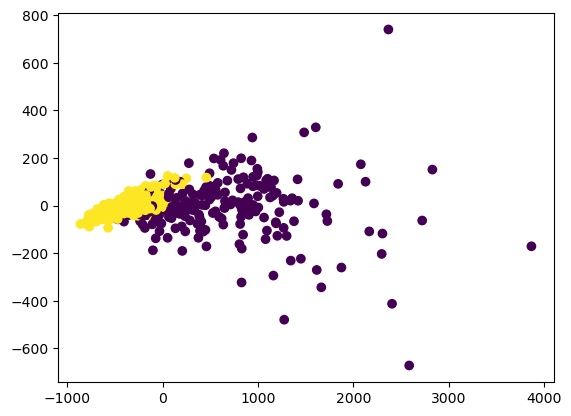

In [64]:
plt.scatter(X_pca[:,0], X_pca[:,1],c=y)
plt.show()

## k Means

In [65]:
X_pca = pca.transform(X)


# learn the model
kmeans_model = kmeans_algo.fit(X_pca)

# return centroids
kmeans_model.cluster_centers_
labels = kmeans_model.labels_


c:\Users\danim\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [66]:
print("means:\n",kmeans_model.cluster_centers_)

means:
 [[ 1.02482043e+03  1.58741196e+00]
 [-3.06510219e+02 -4.74773896e-01]]


In [67]:
# compute silhouette
print("Silhouette:",metrics.silhouette_score(X_pca, labels, metric='euclidean'))

Silhouette: 0.6984195775999954


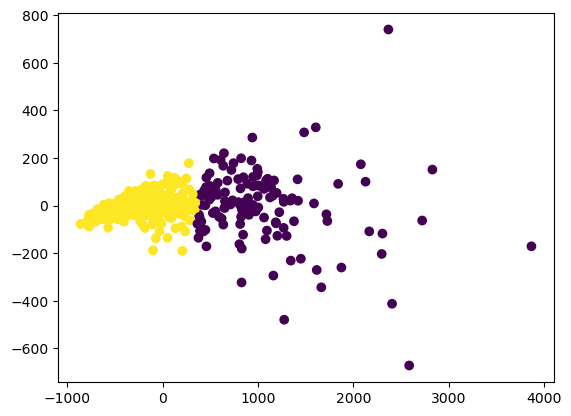

In [71]:

plt.scatter(X_pca[:,0], X_pca[:,1],c=labels)
plt.show()


## EM Clustering

c:\Users\danim\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


Silhouette: 0.5865823748565955


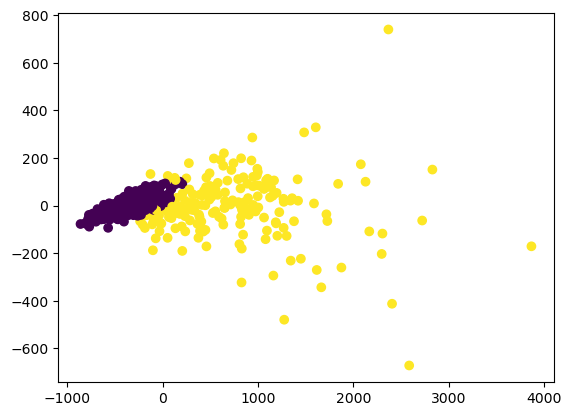

In [73]:
em_model = em_algo.fit(X_pca)
labels_em= em_model.predict(X_pca)
# compute silhouette
print("Silhouette:",metrics.silhouette_score(X_pca, labels_em, metric='euclidean'))

plt.scatter(X_pca[:,0], X_pca[:,1],c=labels_em)
plt.show()